In [1]:
import os
import copy
import math
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl import okhs
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.fractional_dmd import FractionalDMD, plot_forecast_diagnostics
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.gram_transform import OKHSTransformer
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.fractional_liouville import FractionalLiouvilleOperator
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.column_sampling_decomposition import CURDecomposition
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.kernels import DeepKernel
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.deep_fractional_loss import DeepFractionalDMDLoss
from fedot_ind.core.operation.decomposition.matrix_decomposition.method_impl.deep_okhs.deep_fdmd_net import DeepFDMDAutoencoder

from kernel_dmd import ClassicalKernelDMD, build_classical_kdmd

from okhs_experiment_utils import ExperimentConfig
from example_common import (generate_trajectories_pycaputo, 
                            RBFKernel, 
                            rhs_lotka_volterra, 
                            rhs_linear, 
                            rhs_logistic, 
                            rhs_quadratic,
                            rhs_mu_cubic,
                            rhs_pendulum,
                            rhs_van_der_pol,
                            rhs_stuart_landau,

                            EncoderAdapter,
                            plot_training_loss,
                            plot_eigenvalues,
)

c:\Users\nikik\Documents\Programming\Fedot.Industrial\.venv\lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [97]:
def compare_models_and_visualize(deep_fdmd, baseline_fdmd, classical_kdmd, test_trajectories, time_grid, config, n_plots=3):
    """Вычисляет ошибки на тесте, выводит сравнительную таблицу и строит графики для трех моделей."""
    initial_len = config.initial_segment_length

    print("\n" + "="*75)
    print(f"{'Траектория':<12} | {'Baseline MSE':<15} | {'Classical DMD MSE':<19} | {'Deep OKHS MSE':<15}")
    print("-" * 75)

    n_plots = min(n_plots, len(test_trajectories))
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 5 * n_plots))
    if n_plots == 1:
        axes = [axes]

    mean_baseline_mse = 0.0
    mean_classical_mse = 0.0
    mean_deep_mse = 0.0

    for i, test_traj in enumerate(test_trajectories):
        init_seg = test_traj[:initial_len]
        target_future = test_traj[initial_len:]

        pred_deep = deep_fdmd.predict(init_seg, time_grid, return_tensor=False)
        pred_base = baseline_fdmd.predict(init_seg, time_grid, return_tensor=False) 
        pred_class = classical_kdmd.predict(init_seg, time_grid, return_tensor=False)
        
        future_deep = pred_deep[initial_len:]
        future_base = pred_base[initial_len:]
        future_class = pred_class[initial_len:]
        
        mse_deep = np.mean((target_future - future_deep)**2)
        mse_base = np.mean((target_future - future_base)**2)
        mse_class = np.mean((target_future - future_class)**2)
        
        mean_deep_mse += mse_deep
        mean_baseline_mse += mse_base
        mean_classical_mse += mse_class

        if i < 10: 
            print(f"Test #{i:<7} | {mse_base:<15.4e} | {mse_class:<19.4e} | {mse_deep:<15.4e}")

        if i < n_plots:
            ax = axes[i]
            dim_idx = 0 
            ax.plot(time_grid[:], test_traj[:, dim_idx], 'k--', linewidth=2, label="Ground Truth")
            ax.plot(time_grid[:initial_len], init_seg[:, dim_idx], 'ko-', markersize=4, alpha=0.5, label="Initial Segment")
            ax.plot(time_grid, pred_base[:, dim_idx], 'r-', alpha=0.7, label="Baseline (RBF)")
            # ax.plot(time_grid, pred_class[:, dim_idx], 'b-', alpha=0.7, label="Classical Kernel DMD")
            ax.plot(time_grid, pred_deep[:, dim_idx], 'g-', linewidth=2, alpha=0.8, label="Deep OKHS")
            ax.axvline(x=time_grid[initial_len-1], color='gray', linestyle=':')
            ax.set_title(f"Прогноз тестовой траектории")
            ax.set_xlabel("Time")
            ax.legend()
            ax.grid(True, alpha=0.3)
            
    mean_baseline_mse /= len(test_trajectories)
    mean_classical_mse /= len(test_trajectories)
    mean_deep_mse /= len(test_trajectories)
    
    print("-" * 75)
    print(f"{'MEAN MSE':<12} | {mean_baseline_mse:<15.4e} | {mean_classical_mse:<19.4e} | {mean_deep_mse:<15.4e}")
    print("="*75 + "\n")

    plt.tight_layout()
    plt.show() 
    return time_grid, pred_deep, pred_base, pred_class

In [3]:
def evaluate_full_pipeline(autoencoder, W, basis_trajectories, val_trajectories, time_grid, config, device):
    """Изолированный прогон пайплайна для оценки реального качества (выполняется в no_grad)."""
    autoencoder.eval()
    
    kernel = DeepKernel(feature_extractor=EncoderAdapter(autoencoder), base_kernel=None).to(device)
    okhs = OKHSTransformer(kernel=kernel, q=config.q_true, n_quad_points=config.n_quad_points, dt=float(time_grid[1] - time_grid[0]), device=device)
    # liouville = FractionalLiouvilleOperator(okhs_transformer=okhs, ready_operator=W, n_quad_points=config.n_quad_points)
    liouville = FractionalLiouvilleOperator(okhs_transformer=okhs, n_quad_points=config.n_quad_points)
    fdmd = FractionalDMD(liouville_operator=liouville, n_quad_points=config.n_quad_points, regularization=config.regularization, device=device)
    
    with torch.no_grad():
        okhs.fit(basis_trajectories)
        liouville.fit()
        fdmd.fit()
        
        val_mse = 0.0
        for val_traj in val_trajectories:
            init_seg = val_traj[:config.initial_segment_length]
            target_seg = torch.tensor(val_traj[config.initial_segment_length:], dtype=torch.float64, device=device)
            
            pred_tensor = fdmd.predict(initial_trajectory=init_seg, t_span=time_grid, return_tensor=True)
            pred_future = pred_tensor[config.initial_segment_length:]
            val_mse += torch.nn.functional.mse_loss(pred_future, target_seg).item()
        val_mse /= len(val_trajectories)

        eig_vals = liouville.eigenvalues_
        max_real_eig = torch.max(eig_vals.real).item()
        cond_G = okhs.gram_condition_number_
        max_mode_norm = torch.max(torch.norm(fdmd.modes_, dim=-1)).item()
        
        val_sample = torch.tensor(val_trajectories[0], dtype=torch.float64, device=device)
        z_val = autoencoder.encode_trajectory(val_sample)
        latent_drift = torch.mean(torch.norm(z_val[..., :config.dim] - val_sample, dim=-1)).item()
            
    return val_mse, max_real_eig, cond_G, latent_drift, max_mode_norm, eig_vals.cpu().numpy()

In [4]:
def train_deep_fdmd_pipeline(config, trajectories, time_grid, epochs=100, lr=1e-3, lambda_adj=1.0, device='cuda'):
    print(f"\n--- Инициализация Deep fDMD на {device.upper()} ---")
    
    log_dir = os.path.join("runs", config.name.replace(" ", "_").replace(":", ""))
    writer = SummaryWriter(log_dir=log_dir)
    print(f"TensorBoard логирование в: {log_dir}")
    
    n_basis = int(len(trajectories) * 0.6)
    n_val = int(len(trajectories) * 0.3)
    
    raw_basis = trajectories[:n_basis]
    val_traj = trajectories[n_basis:n_basis + n_val]
    test_traj = trajectories[n_basis + n_val:]

    cur_decomposer = CURDecomposition(params={'tolerance': [0.1], "rank": 40})
    cur_decomposer.fit_transform(np.array([traj.flatten() for traj in raw_basis]))
    basis_traj = [raw_basis[i] for i in np.sort(cur_decomposer.row_indices)]
    print(f"Выбрано {len(basis_traj)} базисных траекторий из {len(raw_basis)} (CUR Decomposition)")
    
    x_train_tensor = torch.tensor(np.array(basis_traj), dtype=torch.float64, device=device)
    
    latent_dim = 40
    model = DeepFDMDAutoencoder(input_dim=config.dim, latent_dim=latent_dim, dtype=torch.float64).to(device)

    # Быстрое обучение OKHS для инициализации TimeGridManager
    okhs = OKHSTransformer(kernel=RBFKernel(gamma=1.0), q=config.q_true, n_quad_points=config.n_quad_points, dt=float(time_grid[1] - time_grid[0]), device=device)
    okhs.fit(basis_traj)  
    
    # Получаем отнормированную сетку и длительности из менеджера
    # t_grid_norm = okhs.time_manager.train_t_grids_norm_[0]
    # T_norm_tensor = torch.full((x_train_tensor.shape[0],), t_grid_norm[-1].item(), dtype=torch.float64, device=device)
    
    t_grid_batch = torch.stack(okhs.time_manager.train_t_grids_norm_).to(device)
    T_norm_tensor = torch.full((x_train_tensor.shape[0],), t_grid_batch[0, -1].item(), dtype=torch.float64, device=device)
    
    liouville = FractionalLiouvilleOperator(okhs_transformer=okhs, n_quad_points=config.n_quad_points)
    liouville.fit()
    
    adjoint_loss_fn = DeepFractionalDMDLoss(latent_dim=latent_dim, q=config.q_true, n_quad_points=config.n_quad_points, device=device)
    recon_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(list(model.parameters()) + list(adjoint_loss_fn.parameters()), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=False)

    history = {
        "loss": [], "max_real_eig": [], "cond_g": [], "drift": [], "max_mode_norm": [],
        "train_recon": [], "train_adj": [], "W_eigenvalues": [], "liouville_eigenvalues": [], "W*_eigenvalues": []
    }
    
    best_val_mse = float('inf')
    best_model_state = copy.deepcopy(model.state_dict())

    pbar = tqdm(range(1, epochs + 1), desc="Training Phase")
    
    for epoch in pbar:
        model.train()
        optimizer.zero_grad()
        
        # 1. Запрашиваем узлы коллокации у лосса (в нормированном времени tau)
        t_k, tau_nodes = adjoint_loss_fn.get_collocation_nodes(T_norm_tensor)
        
        # 2. Интерполируем исходные траектории X в узлах
        x_tk = okhs.time_manager.interpolate_batch(x_train_tensor, t_grid_batch, t_k)
        x_nodes = okhs.time_manager.interpolate_batch(x_train_tensor, t_grid_batch, tau_nodes)
        x_start = x_train_tensor[:, 0, :]
        
        # 3. Переводим интерполированные точки в латентное пространство (Decoupled Preprocessing)
        z_start = model.encode_trajectory(x_start)
        z_tk = model.encode_trajectory(x_tk)
        z_nodes = model.encode_trajectory(x_nodes)
        
        # 4. Считаем ошибку невязки Лиувилля
        loss_adj = adjoint_loss_fn(z_start, z_tk, z_nodes, t_k)
        
        # 5. Считаем ошибку реконструкции на всей траектории
        _, x_recon = model(x_train_tensor)
        loss_recon = recon_loss_fn(x_recon, x_train_tensor)
        
        loss = loss_recon + lambda_adj * loss_adj
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        history['train_recon'].append(loss_recon.item())
        history['train_adj'].append(loss_adj.item())

        W = adjoint_loss_fn.W.detach().cpu().numpy()

        val_mse, max_real, cond_g, drift, max_norm, liouville_eigenvalues = evaluate_full_pipeline(
            model, W, basis_traj, val_traj, time_grid, config, device
        )
        
        history["loss"].append(val_mse)
        history["max_real_eig"].append(max_real)
        history["cond_g"].append(cond_g)
        history["drift"].append(drift)
        history["max_mode_norm"].append(max_norm)
        history["W_eigenvalues"].append(np.linalg.eigvals(adjoint_loss_fn.W.detach().cpu().numpy()))
        history["liouville_eigenvalues"].append(liouville_eigenvalues)
        history["W*_eigenvalues"].append(np.linalg.eigvals(adjoint_loss_fn.W.detach().cpu().numpy().T))
        scheduler.step(val_mse)
        pbar.set_postfix({'Val MSE': f"{val_mse:.2e}", 'Cond(G)': f"{cond_g:.1e}"})
        
        writer.add_scalar('Loss/Reconstruction', loss_recon.item(), epoch)
        writer.add_scalar('Loss/Adjoint', loss_adj.item(), epoch)
        writer.add_scalar('Loss/Total', loss.item(), epoch)
        writer.add_scalar('Validation/MSE', val_mse, epoch)
        writer.add_scalar('LearningRate', optimizer.param_groups[0]['lr'], epoch)
        
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_model_state = copy.deepcopy(model.state_dict())

    print(f"\nОбучение завершено. Лучший Val MSE: {best_val_mse:.4e}")
    model.load_state_dict(best_model_state)
    writer.close()
    
    return model, adjoint_loss_fn.W, basis_traj, test_traj, history


In [5]:
def build_okhs(trained_autoencoder = None, basis_trajectories = None, time_grid = None, config = None, device = None):
    if trained_autoencoder is not None:
        deep_kernel = DeepKernel(feature_extractor=EncoderAdapter(trained_autoencoder), base_kernel=None).to(device)
        okhs = OKHSTransformer(kernel=deep_kernel, q=config.q_true, n_quad_points=config.n_quad_points, dt=float(time_grid[1] - time_grid[0]), device=device)
    else :
        okhs = OKHSTransformer(kernel=RBFKernel(gamma=1.0), q=config.q_true, n_quad_points=config.n_quad_points, dt=float(time_grid[1] - time_grid[0]), device=device)
    okhs.fit(basis_trajectories)  
    liouville = FractionalLiouvilleOperator(okhs_transformer=okhs, n_quad_points=config.n_quad_points)
    liouville.fit()
    trained_okhs = FractionalDMD(liouville_operator=liouville, n_quad_points=config.n_quad_points, regularization=config.regularization, device=device)
    trained_okhs.fit(basis_trajectories)
    return trained_okhs

In [6]:
device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_str)
device

device(type='cuda')

In [7]:
cases = [
        dict(
            config=ExperimentConfig(
                name="Linear",
                q_true=0.8,
                dim=2,
                n_train_traj=100,
                n_steps_train=500,
                T_max_train=5.0,
                initial_segment_length=105,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=-1.0,
                ic_high=1.0,
            ),
            dynamics_func=rhs_linear,
            dynamics_args=(-2.0,),
            kernel=RBFKernel(gamma=1.5),
        ),
        dict(
            config=ExperimentConfig(
                name="Logistic",
                q_true=0.8,
                dim=1,
                n_train_traj=150,
                n_steps_train=500,
                T_max_train=3.0,
                initial_segment_length=155,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=0.1,
                ic_high=0.9,
            ),
            dynamics_func=rhs_logistic,
            dynamics_args=(1.5,),
            kernel=RBFKernel(gamma=2.0),
        ),
        dict(
            config=ExperimentConfig(
                name="Quadratic",
                q_true=0.8,
                dim=1,
                n_train_traj=250,
                n_steps_train=700,
                T_max_train=5.0,
                initial_segment_length=255,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=0.1,
                ic_high=2.0,
            ),
            dynamics_func=rhs_quadratic,
            dynamics_args=(2.0, 1.0),
            kernel=RBFKernel(gamma=3.0),
        ),
        dict(
            config=ExperimentConfig(
                name="Lotka-Volterra",
                q_true=0.8,
                dim=2,
                n_train_traj=200,
                n_steps_train=500,
                T_max_train=5.0,
                initial_segment_length=205,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=0.5,
                ic_high=2.0,
            ),
            dynamics_func=rhs_lotka_volterra,
            dynamics_args=(1.5, 1.0, 3.0, 1.0),
            kernel=RBFKernel(gamma=2.5),
        ),
        dict(
            config=ExperimentConfig(
                name="Fractional Pendulum",
                q_true=0.4,
                dim=2,
                n_train_traj=200,
                n_steps_train=600,
                T_max_train=8.0,
                initial_segment_length=205,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=-2.0,  # Ограничиваем, чтобы избежать слишком быстрых вращений (v >> 0)
                ic_high=2.0,
            ),
            dynamics_func=rhs_pendulum,
            dynamics_args=(1.0,), # omega = 1.0
            kernel=RBFKernel(gamma=1.5),
        ),
        dict(
            config=ExperimentConfig(
                name="Van der Pol Oscillator",
                q_true=0.9, # q=0.9 для более выраженного предельного цикла
                dim=2,
                n_train_traj=90,
                n_steps_train=600,
                T_max_train=10.0,
                initial_segment_length=255,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=-2.5,
                ic_high=2.5,
            ),
            dynamics_func=rhs_van_der_pol,
            dynamics_args=(1.0,), # mu = 1.0
            kernel=RBFKernel(gamma=2.0),
        ),
        dict(
            config=ExperimentConfig(
                name="Stuart-Landau",
                q_true=0.85,
                dim=2,
                n_train_traj=90,
                n_steps_train=600,
                T_max_train=8.0,
                initial_segment_length=205,
                n_quad_points=30,
                regularization=1e-7,
                plot_part=1.0,
                seed=42,
                ic_low=-1.5,
                ic_high=1.5,
            ),
            dynamics_func=rhs_stuart_landau,
            dynamics_args=(1.0, 2.0), # mu = 1.0, omega = 2.0
            kernel=RBFKernel(gamma=2.5),
        ),
    ]

In [9]:
for i, case in enumerate(cases):
    print(i, case['config'].name)

0 Linear
1 Logistic
2 Quadratic
3 Lotka-Volterra
4 Fractional Pendulum
5 Van der Pol Oscillator
6 Stuart-Landau


In [92]:
case_ = cases[0]

In [93]:
config = case_["config"]
print(f"\n\n=== Запуск эксперимента: {config.name} ===")
time_grid, trajectories = generate_trajectories_pycaputo(
    case_["dynamics_func"],
    *case_["dynamics_args"],
    n_trajectories=config.n_train_traj,
    q_true=config.q_true,
    n_steps=config.n_steps_train,
    T_max=config.T_max_train,
    dim=config.dim,
    seed=config.seed,
    ic_low=config.ic_low,
    ic_high=config.ic_high,
    # noise_std=0.05, 
)

trained_autoencoder, W, basis_trajectories, test_traj, history = train_deep_fdmd_pipeline(
    config=config, 
    trajectories=trajectories, 
    time_grid=time_grid, 
    epochs=20, 
    lr=1e-3,
    device=device_str
)



=== Запуск эксперимента: Linear ===

--- Инициализация Deep fDMD на CUDA ---
TensorBoard логирование в: runs\Linear
Выбрано 40 базисных траекторий из 60 (CUR Decomposition)


Training Phase:   0%|          | 0/20 [00:00<?, ?it/s]


Обучение завершено. Лучший Val MSE: 1.3463e-07


In [95]:
print("\nСборка финального пайплайна Deep fDMD...")
deep_okhs = build_okhs(trained_autoencoder=trained_autoencoder, basis_trajectories=basis_trajectories, time_grid=time_grid, config=config, device=device)

print("Обучение Baseline (обычный RBF Kernel)...")
okhs_base = build_okhs(trained_autoencoder=None, basis_trajectories=basis_trajectories, time_grid=time_grid, config=config, device=device)


Сборка финального пайплайна Deep fDMD...
Обучение Baseline (обычный RBF Kernel)...


Обучение Classical Kernel DMD...
[Kernel DMD] Отфильтровано нестабильных мод: 3 из 1000

Траектория   | Baseline MSE    | Classical DMD MSE   | Deep OKHS MSE  
---------------------------------------------------------------------------
Test #0       | 2.1048e-07      | 7.3007e+00          | 3.0319e-07     
Test #1       | 1.5812e-08      | 7.4086e+00          | 1.8151e-09     
Test #2       | 6.6482e-08      | 7.3354e+00          | 1.3312e-07     
Test #3       | 1.0876e-07      | 7.4222e+00          | 5.4140e-08     
Test #4       | 3.7579e-08      | 7.2729e+00          | 8.0149e-08     
Test #5       | 8.8728e-08      | 7.1690e+00          | 2.6699e-07     
Test #6       | 8.1130e-08      | 7.7504e+00          | 1.8975e-07     
Test #7       | 1.5263e-07      | 7.5410e+00          | 2.3399e-07     
Test #8       | 8.8530e-08      | 7.4797e+00          | 3.8117e-08     
Test #9       | 8.5535e-08      | 7.5666e+00          | 1.6699e-07     
--------------------------------------------

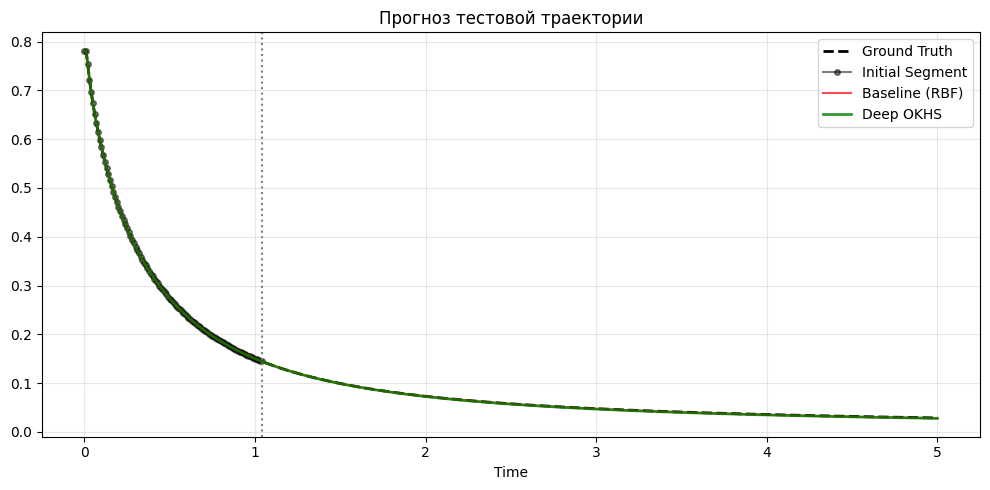

In [99]:
print("Обучение Classical Kernel DMD...")
classical_kdmd = build_classical_kdmd(basis_trajectories=basis_trajectories, time_grid=time_grid, config=config, device=device)

time_grid, pred_deep, pred_base, pred_class = compare_models_and_visualize(
    deep_fdmd=deep_okhs,
    baseline_fdmd=okhs_base,
    classical_kdmd=classical_kdmd,
    test_trajectories=test_traj,
    time_grid=time_grid,
    config=config,
    n_plots=1
)

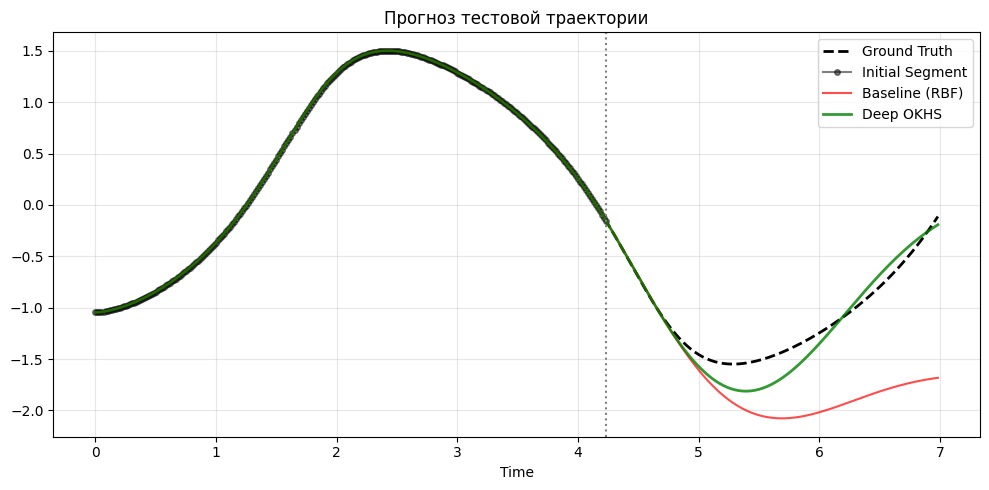

In [91]:
trajectory = test_traj[4]
initial_len = config.initial_segment_length
init_seg = trajectory[:initial_len]
end = len(trajectory) * 7 // 10
target_future = trajectory[initial_len: end]
pred_deep = deep_okhs.predict(init_seg, time_grid, return_tensor=False)
pred_base = okhs_base.predict(init_seg, time_grid, return_tensor=False)
future_deep = pred_deep[initial_len: end]
future_base = pred_base[initial_len: end]

dim_idx = 0
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_grid[:end], trajectory[:end, dim_idx], 'k--', linewidth=2, label="Ground Truth")
ax.plot(time_grid[:initial_len], init_seg[:, dim_idx], 'ko-', markersize=4, alpha=0.5, label="Initial Segment")
ax.plot(time_grid[:end], pred_base[:end, dim_idx], 'r-', alpha=0.7, label="Baseline (RBF)")
# ax.plot(time_grid, pred_class[:, dim_idx], 'b-', alpha=0.7, label="Classical Kernel DMD")
ax.plot(time_grid[:end], pred_deep[:end, dim_idx], 'g-', linewidth=2, alpha=0.8, label="Deep OKHS")
ax.axvline(x=time_grid[initial_len-1], color='gray', linestyle=':')
ax.set_title("Прогноз тестовой траектории")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()